In [218]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


In [217]:

source = '/cosma5/data/durham/dc-pick2/Nbody6ppGPU'
path = source + '/Hyades2/snap.40_240.h5part'

phases = [ 
    (-1, 'Pre-MS',  'skyblue',       0.5),
    (0,  'low MS',  'steelblue',      0.5),
    (1,  'MS',      'dodgerblue',     0.5),
    (2,  'HG',      'khaki',          1),
    (3,  'RGB',     'orange',         1),
    (4,  'CHeB',    'darkorange',     1),
    (5,  'AGB',     'orangered',      1),
    (6,  '2AGB',    'red',            1),
    (7,  'HeMS',    'mediumpurple',   1),
    (8,  'HeHG',    'mediumorchid',   1),
    (9,  'HeGB',    'plum',           1),
    (10, 'WD(He)',  'gray',           1),
    (11, 'WD(CO)',  'silver',         1),
    (12, 'WD(ONe)', 'dimgray',        1),
    (13, 'NS',      'deepskyblue',    1),
    (14, 'BH',      'black',          2),
]
path

'/cosma5/data/durham/dc-pick2/Nbody6ppGPU/Hyades2/snap.40_240.h5part'

In [230]:
!tail -n 10 /cosma5/data/durham/dc-pick2/Nbody6ppGPU/Hyades/output.log

         END RUN    TIME[Myr] =  626.52  TOFF/TIME/TTOT=      0.00000000    260.00000000    260.00000000  CPUTOT =   21.2  ERRTOT = 6.32360D-05  DETOT = 1.02914D-03


        0 INTEGRATION INTERVAL =  260.00    NIRR=          0 NIRRB=     120539 NREG=          0 NKS=          0


          PER TIME UNIT: NIRR= 0.00000D+00 NIRRB= 4.63612D+02 NREG= 0.00000D+00 NKS= 0.00000D+00
  MYDUMP     260.0000000000000      260                             1 
 comm.1_260                 
  Total CPU=    1270.851805061102     


In [156]:
with h5py.File(path, 'r') as f:
    #f.visititems(print)
    print(list(f.keys()))

['Step#0', 'Step#1', 'Step#10', 'Step#100', 'Step#101', 'Step#102', 'Step#103', 'Step#104', 'Step#105', 'Step#106', 'Step#107', 'Step#108', 'Step#109', 'Step#11', 'Step#110', 'Step#111', 'Step#112', 'Step#113', 'Step#114', 'Step#115', 'Step#116', 'Step#117', 'Step#118', 'Step#119', 'Step#12', 'Step#120', 'Step#121', 'Step#122', 'Step#123', 'Step#124', 'Step#125', 'Step#126', 'Step#127', 'Step#128', 'Step#129', 'Step#13', 'Step#130', 'Step#131', 'Step#132', 'Step#133', 'Step#134', 'Step#135', 'Step#136', 'Step#137', 'Step#138', 'Step#139', 'Step#14', 'Step#140', 'Step#141', 'Step#142', 'Step#143', 'Step#144', 'Step#145', 'Step#146', 'Step#147', 'Step#148', 'Step#149', 'Step#15', 'Step#150', 'Step#151', 'Step#152', 'Step#153', 'Step#154', 'Step#155', 'Step#156', 'Step#157', 'Step#158', 'Step#159', 'Step#16', 'Step#17', 'Step#18', 'Step#19', 'Step#2', 'Step#20', 'Step#21', 'Step#22', 'Step#23', 'Step#24', 'Step#25', 'Step#26', 'Step#27', 'Step#28', 'Step#29', 'Step#3', 'Step#30', 'Step#31

In [157]:
with h5py.File(path, 'r') as f:
    step = f['Step#159']
    print(list(step.keys()))
    x = step['X1'][:]
    y = step['X2'][:]
    z = step['X3'][:]
    m = step['M'][:]
    #kw = step['KW'][:]
    nam = kw = step['NAM'][:] # starID
    print(dict(step.attrs))


['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
{'N_SINGLE': np.int32(8460), 'Time': np.float64(260.0)}


In [114]:
with open(source + '/Hyades/status.36', 'r') as f:
    for i, line in enumerate(f):
        print(line)
        if i > 20:
            break

   0.00000000       0.00000000       6.81564856       224.513458       2000.00757       2000.00757       0.00000000      -4186752.50       3.00066113       0.00000000      -3.55274011E-07   2.85216455E-08   5.90419020E-08   818.069824       5704.73828       59.8075714     -0.249999821      0.250000119     -0.499999940       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000       0.00000000            8472        8472           0           0        8472  0.184627354      0.384649187      0.998056471       1.78866708       3.00066113       4.78739023       8.64667130       17.8862782      0.958058119              12          82         881        2463        4401        6161        7903        8472         817  0.169001877      0.279597253      0.227181897      0.243650109      0.227251291      0.227311566      0.227764681      0.236072510      0.224181190      0.962026417       8.58104751E-02   9.57962200E-0

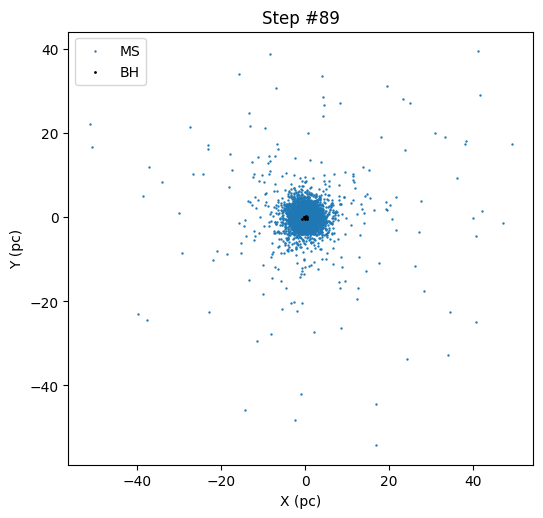

In [28]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(x[kw<=1], y[kw<=1], s=0.5, label='MS')

ax.scatter(x[kw==14], y[kw==14], s=1, label='BH', color='black')
ax.set_xlabel('X (pc)')
ax.set_ylabel('Y (pc)')

ax.legend()
ax.set_aspect('equal')

ax.set_title('Step #89')

plt.show()

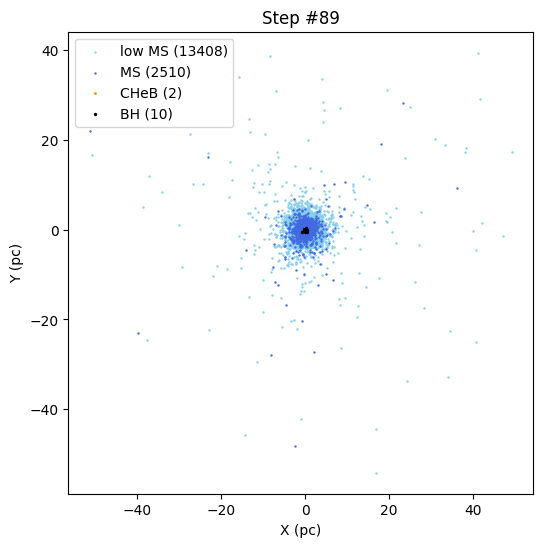

In [36]:
fig, ax = plt.subplots(figsize=(6, 6))

for kw_val, label, color, size in phases:
    mask = kw == kw_val
    if mask.sum() > 0:
        ax.scatter(x[mask], y[mask], s=size, c=color, label=f'{label} ({mask.sum()})')

ax.set_xlabel('X (pc)')
ax.set_ylabel('Y (pc)')
ax.legend()
ax.set_title('Step #89')
plt.show()

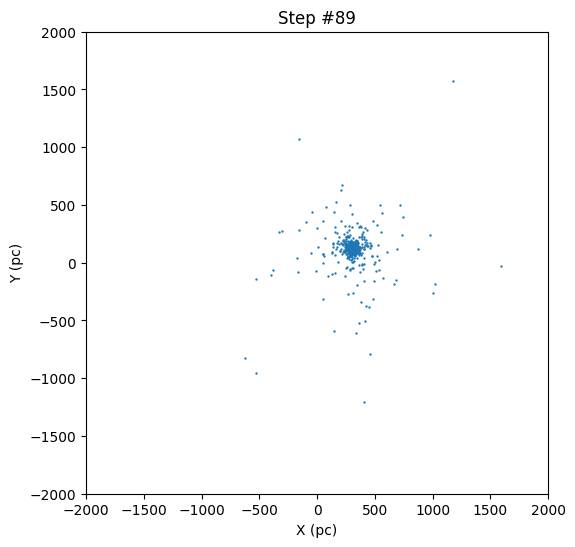

In [59]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(x, y, s=0.5)

ax.set_xlabel('X (pc)')
ax.set_ylabel('Y (pc)')


ax.set_aspect('equal')

ax.set_xlim(-2000, 2000)
ax.set_ylim(-2000, 2000)

ax.set_title('Step #89')

plt.show()

40.0

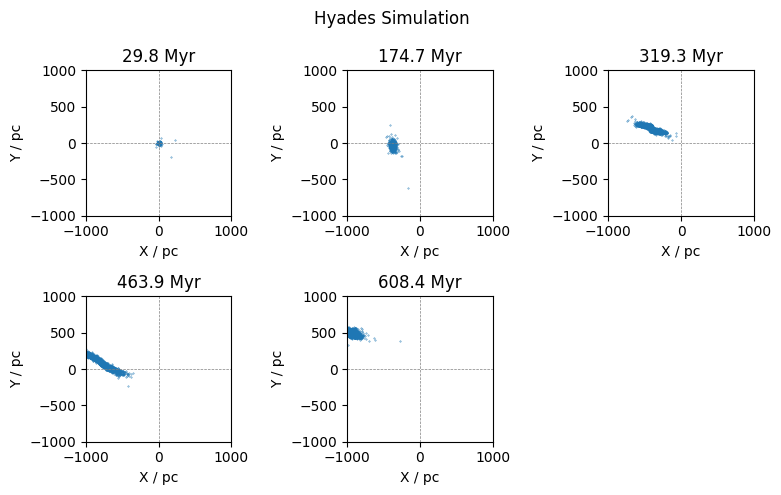

In [137]:
Myr_per_Nbody = 626.52 / 260.0

plty, pltx = 2, 3

fig, axes = plt.subplots(plty, pltx, figsize=(8, 5))

for i, snap in enumerate([0, 60, 120, 180, 240]):
    path = source + f'/Hyades2/snap.40_{snap}.h5part'
    ax = axes[i // pltx][i % pltx]
    
    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody
    
    ax.scatter(x, y, s=0.1)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(f'{t:.1f} Myr')
    ax.set_xlabel('X / pc')
    ax.set_ylabel('Y / pc')
    ax.set_xlim(-1000, 1000)
    ax.set_ylim(-1000, 1000)
    ax.set_aspect('equal')



plt.suptitle("Hyades Simulation")
plt.tight_layout()
axes[1][2].set_visible(False)
plt.show()

    
    

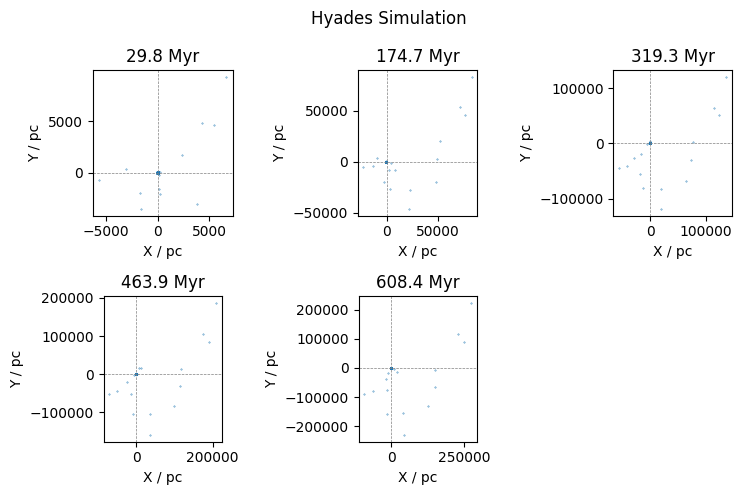

In [141]:
Myr_per_Nbody = 626.52 / 260.0

plty, pltx = 2, 3

fig, axes = plt.subplots(plty, pltx, figsize=(8, 5))

for i, snap in enumerate([0, 60, 120, 180, 240]):
    path = source + f'/Hyades2/snap.40_{snap}.h5part'
    ax = axes[i // pltx][i % pltx]
    
    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody
    
    ax.scatter(x, y, s=0.1)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(f'{t:.1f} Myr')
    ax.set_xlabel('X / pc')
    ax.set_ylabel('Y / pc')
    ax.set_aspect('equal')



plt.suptitle("Hyades Simulation")
plt.tight_layout()
axes[1][2].set_visible(False)
plt.show()

    
    

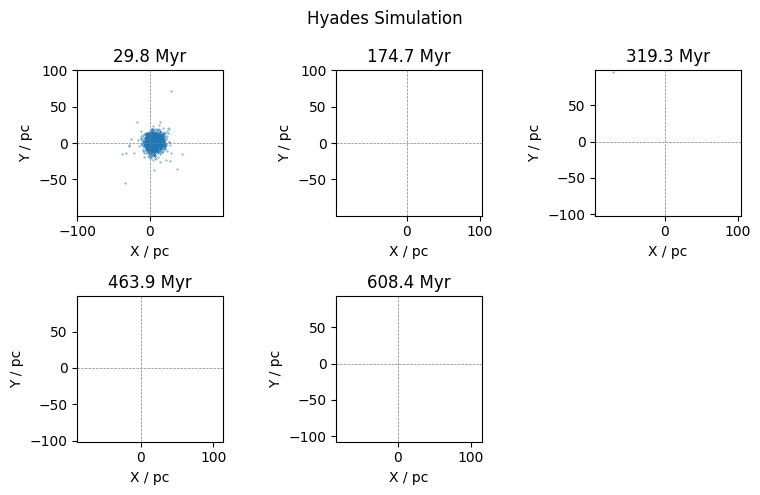

In [145]:
Myr_per_Nbody = 626.52 / 260.0



plty, pltx = 2, 3

fig, axes = plt.subplots(plty, pltx, figsize=(8, 5))

for i, snap in enumerate([0, 60, 120, 180, 240]):
    path = source + f'/Hyades2/snap.40_{snap}.h5part'
    ax = axes[i // pltx][i % pltx]
    
    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody
        
    com_x = np.average(x, weights=m)
    com_y = np.average(y, weights=m)
    
    ax.scatter(x, y, s=0.1)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(f'{t:.1f} Myr')
    ax.set_xlabel('X / pc')
    ax.set_ylabel('Y / pc')
    ax.set_xlim(com_x - 100, com_x + 100)
    ax.set_ylim(com_y - 100, com_y + 100)
    ax.set_aspect('equal')



plt.suptitle("Hyades Simulation")
plt.tight_layout()
axes[1][2].set_visible(False)
plt.show()

    
    

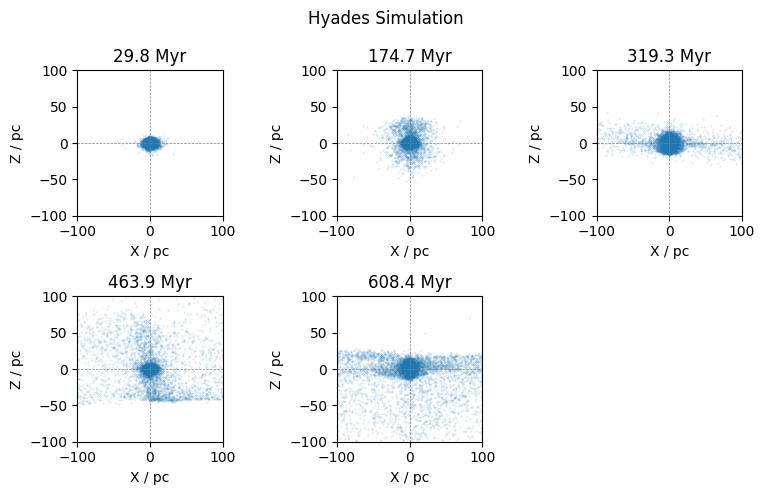

In [216]:
Myr_per_Nbody = 626.52 / 260.0

offset = 100

plty, pltx = 2, 3

fig, axes = plt.subplots(plty, pltx, figsize=(8, 5))

for i, snap in enumerate([0, 60, 120, 180, 240]):
    path = source + f'/Hyades2/snap.40_{snap}.h5part'
    ax = axes[i // pltx][i % pltx]
    
    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

    m_clip = np.clip(m, None, np.percentile(m, 50))
        
    com_x = np.median(x)
    com_z = np.median(z)
    
    ax.scatter(x - com_x, z - com_z, s=0.1, alpha=0.25)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(f'{t:.1f} Myr')
    ax.set_xlabel('X / pc')
    ax.set_ylabel('Z / pc')
    ax.set_xlim(-offset, offset)
    ax.set_ylim(- offset, offset)
    ax.set_aspect('equal')



plt.suptitle("Hyades Simulation")
plt.tight_layout()
axes[1][2].set_visible(False)
plt.show()

    



2.4096877971719843

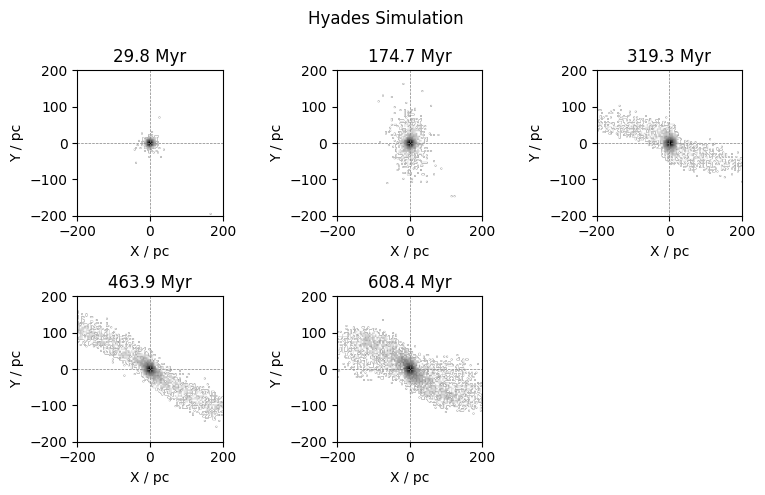

In [231]:
Myr_per_Nbody = 0.36627254517014160E+03/ 0.15200000000000000E+03

offset = 200

plty, pltx = 2, 3

fig, axes = plt.subplots(plty, pltx, figsize=(8, 5))

for i, snap in enumerate([0, 60, 120, 180, 240]):
    path = source + f'/Hyades/snap.40_{snap}.h5part'
    ax = axes[i // pltx][i % pltx]
    
    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody
        
    #com_x = np.average(x, weights=m)
    #com_z = np.average(z, weights=m)

    com_x = np.median(x)
    com_y = np.median(y)

    hist, xedges, yedges = np.histogram2d(x - com_x, y - com_y, bins=100, range=[[-offset, offset], [-offset, offset]])
    ax.imshow(
    hist.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='gray_r',
    norm=LogNorm()
    )

    
    
   # ax.scatter(x - com_x, z - com_z, s=0.1, alpha=0.25)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(f'{t:.1f} Myr')
    ax.set_xlabel('X / pc')
    ax.set_ylabel('Y / pc')
    ax.set_xlim(-offset, offset)
    ax.set_ylim(- offset, offset)
    ax.set_aspect('equal')



plt.suptitle("Hyades Simulation")
plt.tight_layout()
axes[1][2].set_visible(False)
plt.show()

